In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
from sklearn.metrics import cohen_kappa_score, confusion_matrix

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')

COL_TR, COL_EN = '#e74c3c', '#3498db'

EMO_ORDER = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']
EMO_COLORS = {
    'anger':     '#c0392b',
    'disgust':   '#8e44ad',
    'fear':      '#2c3e50',
    'happiness': '#f39c12',
    'neutral':   '#95a5a6',
    'sadness':   '#2980b9',
}
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv('processed/reviews_full_labeled_final.csv')
topics_df = pd.read_csv('processed/bertopic_tam_topics.csv')
topics_df['words'] = topics_df['Representation'].apply(lambda s: ast.literal_eval(s) if isinstance(s, str) else [])
topics_df['label'] = topics_df['words'].apply(lambda ws: ', '.join(ws[:4]))
topic_label = dict(zip(topics_df['Topic'], topics_df['label']))
topic_label[-1] = 'OUTLIER'

print(f'Yorum: {len(df):,} | Film: {df["imdb_id"].nunique()} | Konu: {(topics_df["Topic"] != -1).sum()}')
print(f'Dil: {dict(df["language"].value_counts())}')
print()
print('Kullanılan duygu sınıfları:', EMO_ORDER)
print()
print(pd.crosstab(df['sentiment_qwen'], df['language'], margins=True))

Yorum: 382,977 | Film: 229 | Konu: 79
Dil: {'en': np.int64(191562), 'tr': np.int64(191415)}

Kullanılan duygu sınıfları: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']

language            en      tr     All
sentiment_qwen                        
anger            44606   53599   98205
disgust           5864    7562   13426
fear             12936   21043   33979
happiness        40271   52946   93217
neutral          64025   37507  101532
sadness          23860   18758   42618
All             191562  191415  382977


## 1. Duygu Dağılımı — TR vs EN

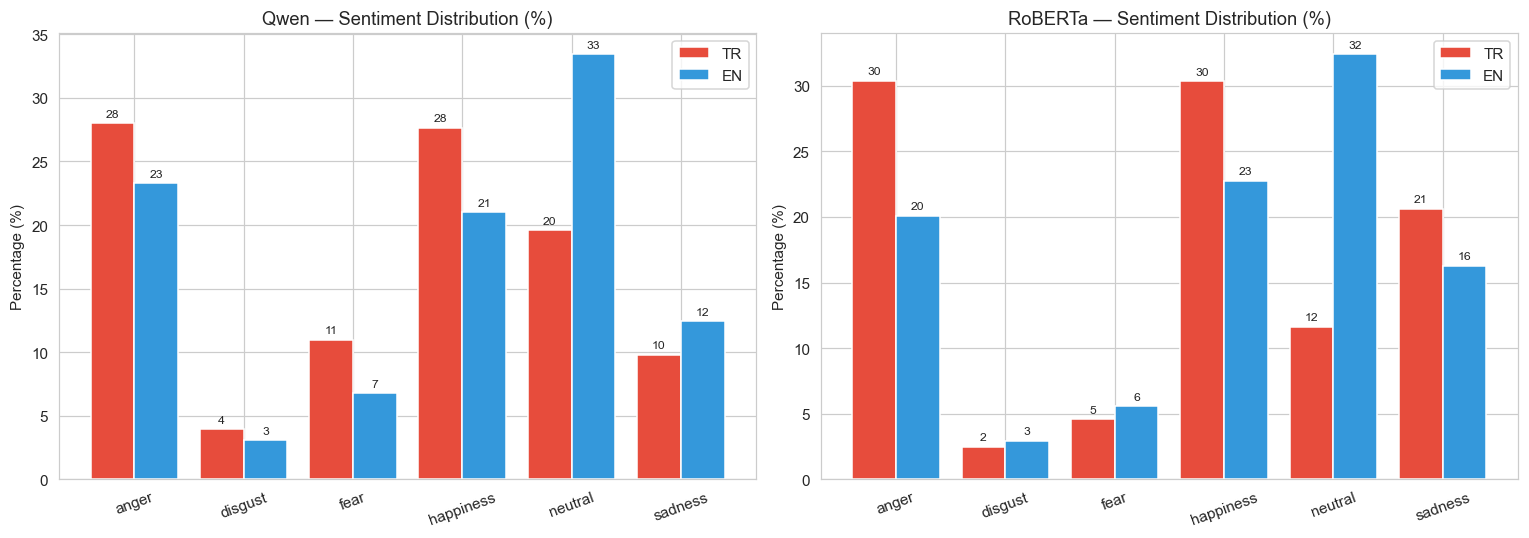

In [10]:
def plot_sentiment_by_lang(col, ax, title):
    ct = pd.crosstab(df[col], df['language']).reindex(EMO_ORDER).fillna(0)
    ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
    x = np.arange(len(EMO_ORDER))
    w = 0.4
    ax.bar(x - w/2, ct_pct['tr'], w, color=COL_TR, label='TR')
    ax.bar(x + w/2, ct_pct['en'], w, color=COL_EN, label='EN')
    ax.set_xticks(x); ax.set_xticklabels(EMO_ORDER, rotation=20)
    
    ax.set_ylabel('Percentage (%)') 
    ax.set_title(title)
    ax.legend()
    for i, (tr_v, en_v) in enumerate(zip(ct_pct['tr'], ct_pct['en'])):
        ax.text(i - w/2, tr_v + 0.5, f'{tr_v:.0f}', ha='center', fontsize=8)
        ax.text(i + w/2, en_v + 0.5, f'{en_v:.0f}', ha='center', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_sentiment_by_lang('sentiment_qwen',    axes[0], 'Qwen — Sentiment Distribution (%)')
plot_sentiment_by_lang('sentiment_roberta', axes[1], 'RoBERTa — Sentiment Distribution (%)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_lang_distribution.png')
plt.show()

## 2. Model Uyumu — RoBERTa vs Qwen


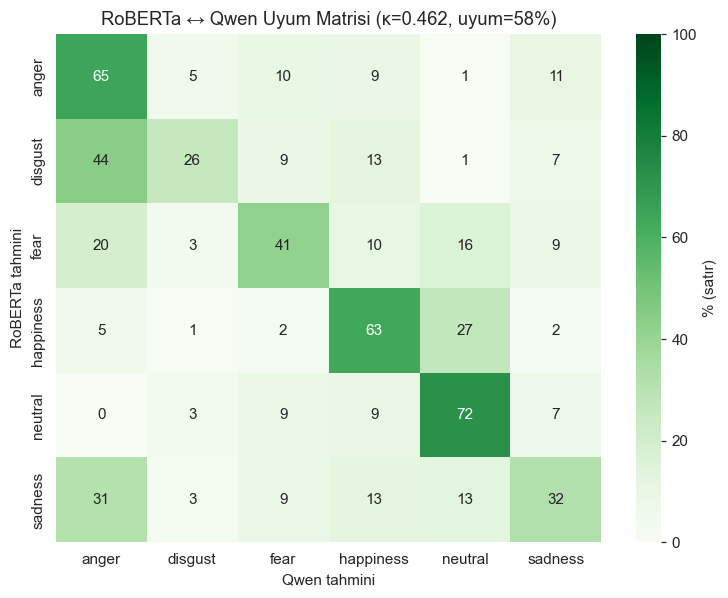

In [11]:
k_all = cohen_kappa_score(df['sentiment_roberta'], df['sentiment_qwen'])
k_tr  = cohen_kappa_score(df[df['language']=='tr']['sentiment_roberta'], df[df['language']=='tr']['sentiment_qwen'])
k_en  = cohen_kappa_score(df[df['language']=='en']['sentiment_roberta'], df[df['language']=='en']['sentiment_qwen'])
agree = (df['sentiment_roberta'] == df['sentiment_qwen']).mean() * 100
agree_tr = (df[df['language']=='tr']['sentiment_roberta'] == df[df['language']=='tr']['sentiment_qwen']).mean() * 100
agree_en = (df[df['language']=='en']['sentiment_roberta'] == df[df['language']=='en']['sentiment_qwen']).mean() * 100


cm = pd.crosstab(df['sentiment_roberta'], df['sentiment_qwen']).reindex(index=EMO_ORDER, columns=EMO_ORDER).fillna(0).astype(int)
cm_norm = cm.div(cm.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.0f', cmap='Greens', vmin=0, vmax=100,
            cbar_kws={'label': '% (satır)'}, ax=ax)
ax.set_xlabel('Qwen tahmini')
ax.set_ylabel('RoBERTa tahmini')
ax.set_title(f'RoBERTa ↔ Qwen Uyum Matrisi (κ={k_all:.3f}, uyum={agree:.0f}%)')
plt.savefig(FIG_DIR / 'model_uyum.png')
plt.show()

## 3. Konu × Duygu — TR ve EN ayrı (Qwen)

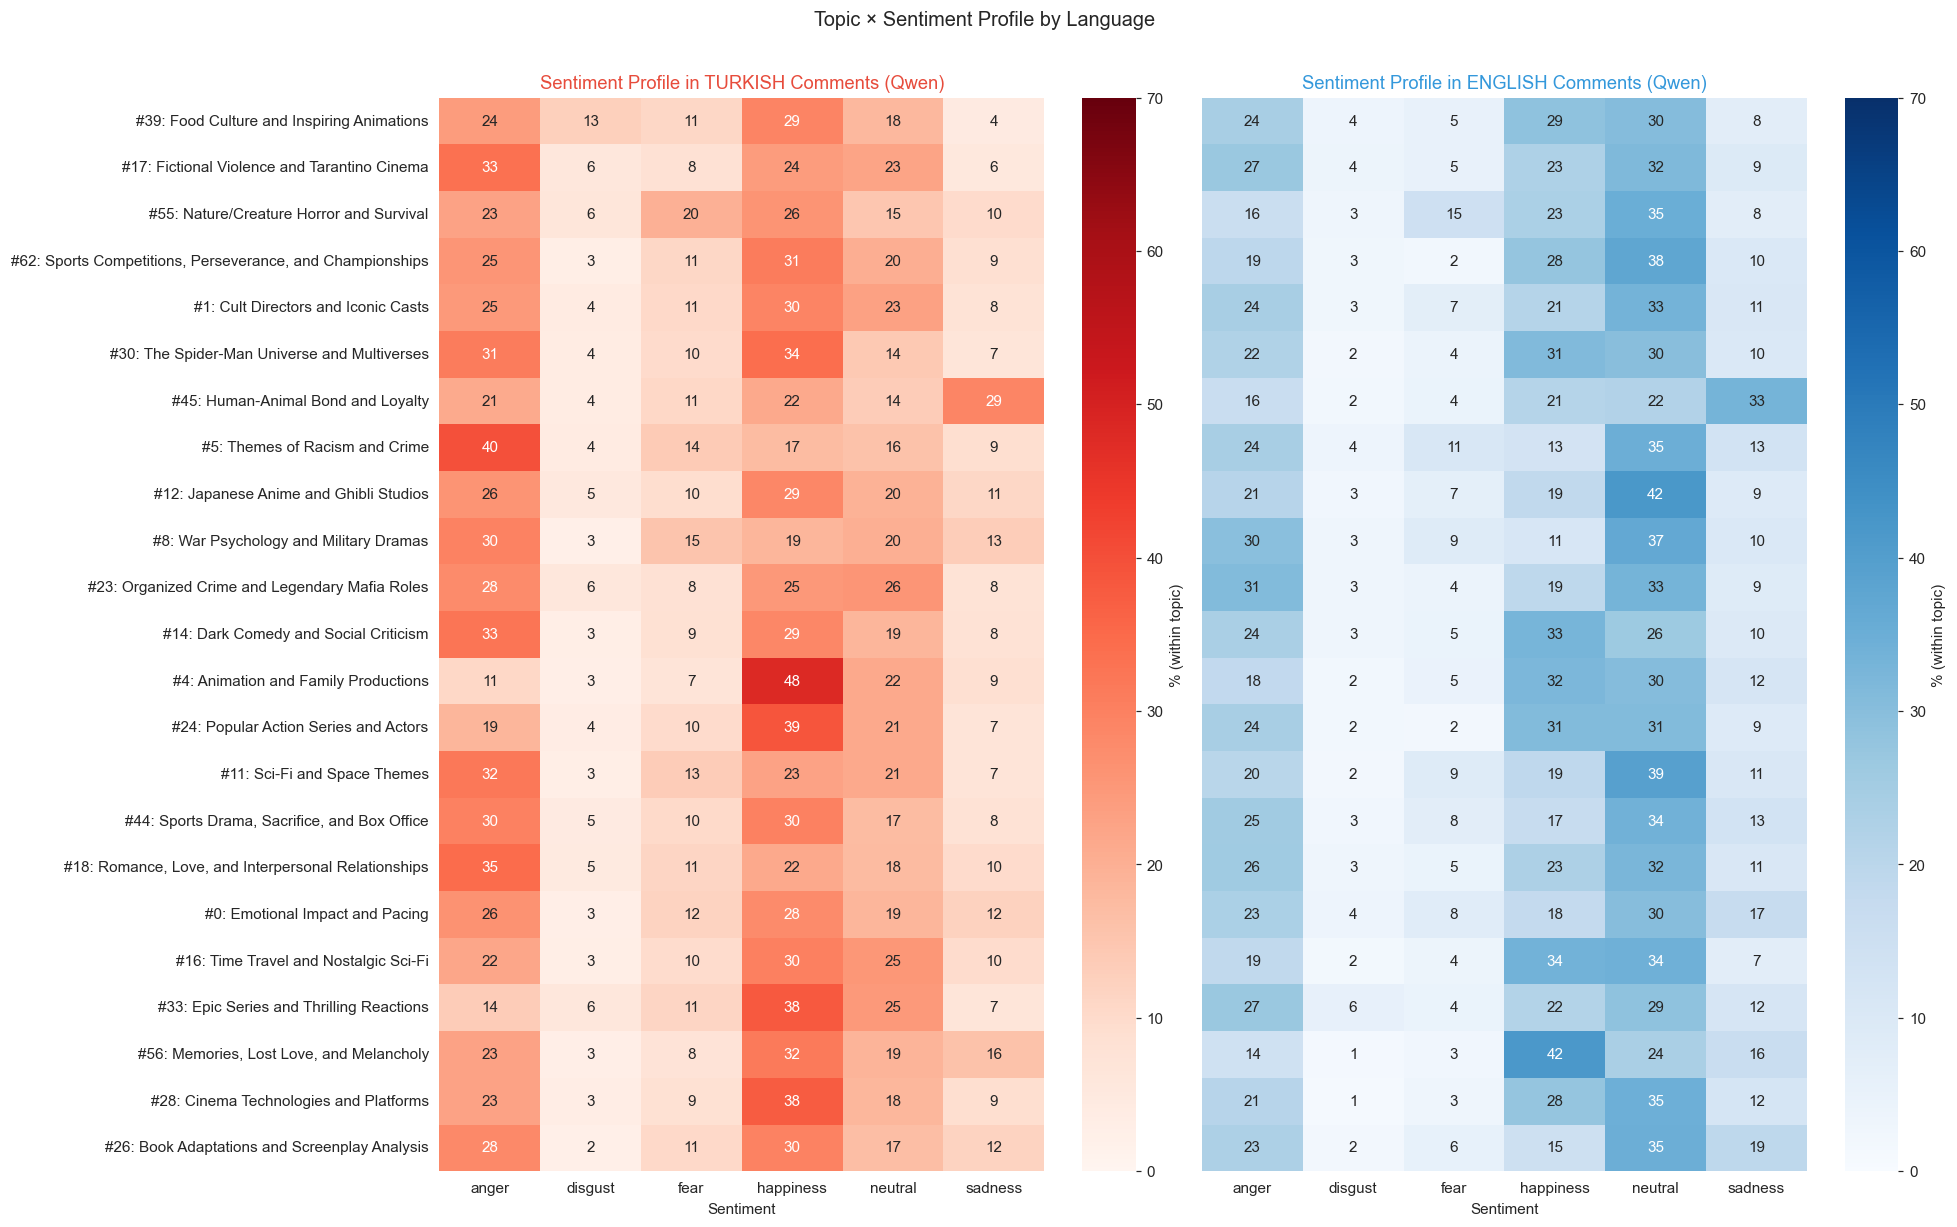

In [12]:
my_topics = [39, 17, 55, 62, 1, 30, 45, 5, 12, 8, 23, 14, 4, 24, 11, 44, 18, 0, 16, 33, 56, 28, 26]  
df_v = df[df['topic'] != -1].copy()
df_v = df_v[df_v['topic'].isin(my_topics)].copy()
top_topics = my_topics
topic_title_dict = dict(zip(topics_df['Topic'], topics_df['Title']))

def lang_emotion_profile(lang):
    """Sentiment percentage for each topic in top_topics for a specific language."""
    mask = (df_v['topic'].isin(top_topics)) & (df_v['language'] == lang)
    ct = pd.crosstab(df_v[mask]['topic'], df_v[mask]['sentiment_qwen'])
    ct = ct.reindex(index=top_topics, columns=EMO_ORDER).fillna(0)
    return ct.div(ct.sum(axis=1), axis=0) * 100

tr_profile = lang_emotion_profile('tr')
en_profile = lang_emotion_profile('en')

labels = [f'#{t}: {topic_title_dict.get(t, f"Topic {t}")}' for t in top_topics]

fig, axes = plt.subplots(1, 2, figsize=(18, 11), sharey=True)

sns.heatmap(tr_profile.set_axis(labels, axis=0),
            annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=70,
            cbar_kws={'label': '% (within topic)'}, ax=axes[0])
axes[0].set_title('Sentiment Profile in TURKISH Comments (Qwen)', fontsize=12, color=COL_TR)
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('')

sns.heatmap(en_profile.set_axis(labels, axis=0),
            annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=70,
            cbar_kws={'label': '% (within topic)'}, ax=axes[1])
axes[1].set_title('Sentiment Profile in ENGLISH Comments (Qwen)', fontsize=12, color=COL_EN)
axes[1].set_xlabel('Sentiment'); axes[1].set_ylabel('')

plt.suptitle(f'Topic × Sentiment Profile by Language', fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig(FIG_DIR / 'topic_sentiment_profile_by_lang.png')
plt.show()

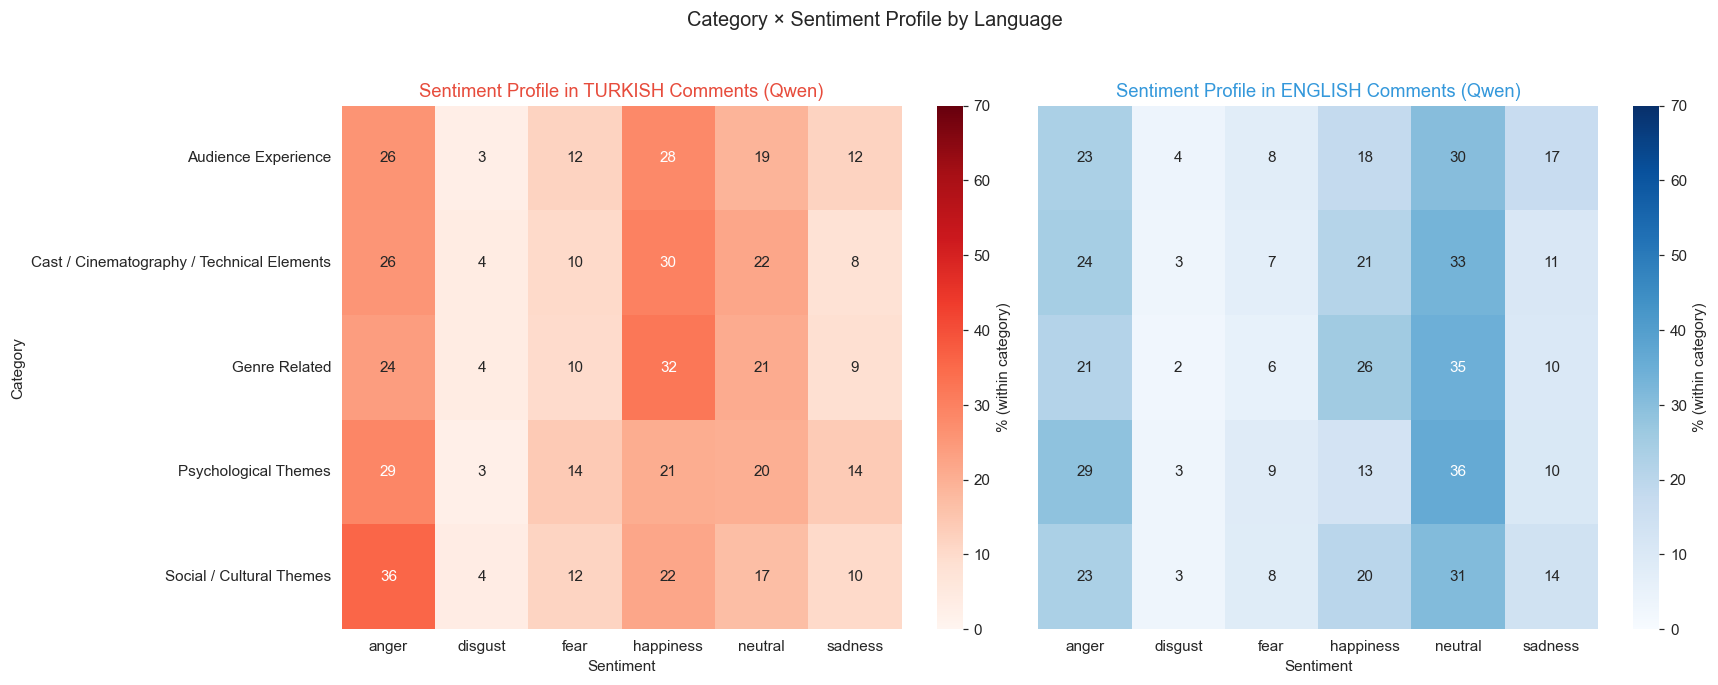

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_category_dict = dict(zip(topics_df['Topic'], topics_df['Category']))

my_topics = [39, 17, 55, 62, 1, 30, 45, 5, 12, 8, 23, 14, 4, 24, 11, 44, 18, 0, 16, 33, 56, 28, 26]  
df_v = df[df['topic'] != -1].copy()
df_v = df_v[df_v['topic'].isin(my_topics)].copy()

df_v['category'] = df_v['topic'].map(topic_category_dict)

unique_categories = sorted(df_v['category'].dropna().unique())

def lang_emotion_profile_by_cat(lang):
    mask = df_v['language'] == lang
    
    ct = pd.crosstab(df_v[mask]['category'], df_v[mask]['sentiment_qwen'])
    
    ct = ct.reindex(index=unique_categories, columns=EMO_ORDER).fillna(0)
    
    return ct.div(ct.sum(axis=1), axis=0) * 100

tr_profile = lang_emotion_profile_by_cat('tr')
en_profile = lang_emotion_profile_by_cat('en')

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.5 * len(unique_categories))), sharey=True)

sns.heatmap(tr_profile,
            annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=70,
            cbar_kws={'label': '% (within category)'}, ax=axes[0])
axes[0].set_title('Sentiment Profile in TURKISH Comments (Qwen)', fontsize=12, color=COL_TR)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Category') 

sns.heatmap(en_profile,
            annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=70,
            cbar_kws={'label': '% (within category)'}, ax=axes[1])
axes[1].set_title('Sentiment Profile in ENGLISH Comments (Qwen)', fontsize=12, color=COL_EN)
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('')

plt.suptitle('Category × Sentiment Profile by Language', fontsize=13, y=1.03)

plt.tight_layout()
plt.savefig(FIG_DIR / 'category_sentiment_profile_by_lang.png', dpi=300)
plt.show()

## 4. Aynı Konu — Farklı Dilde Duygu Karşılaştırması

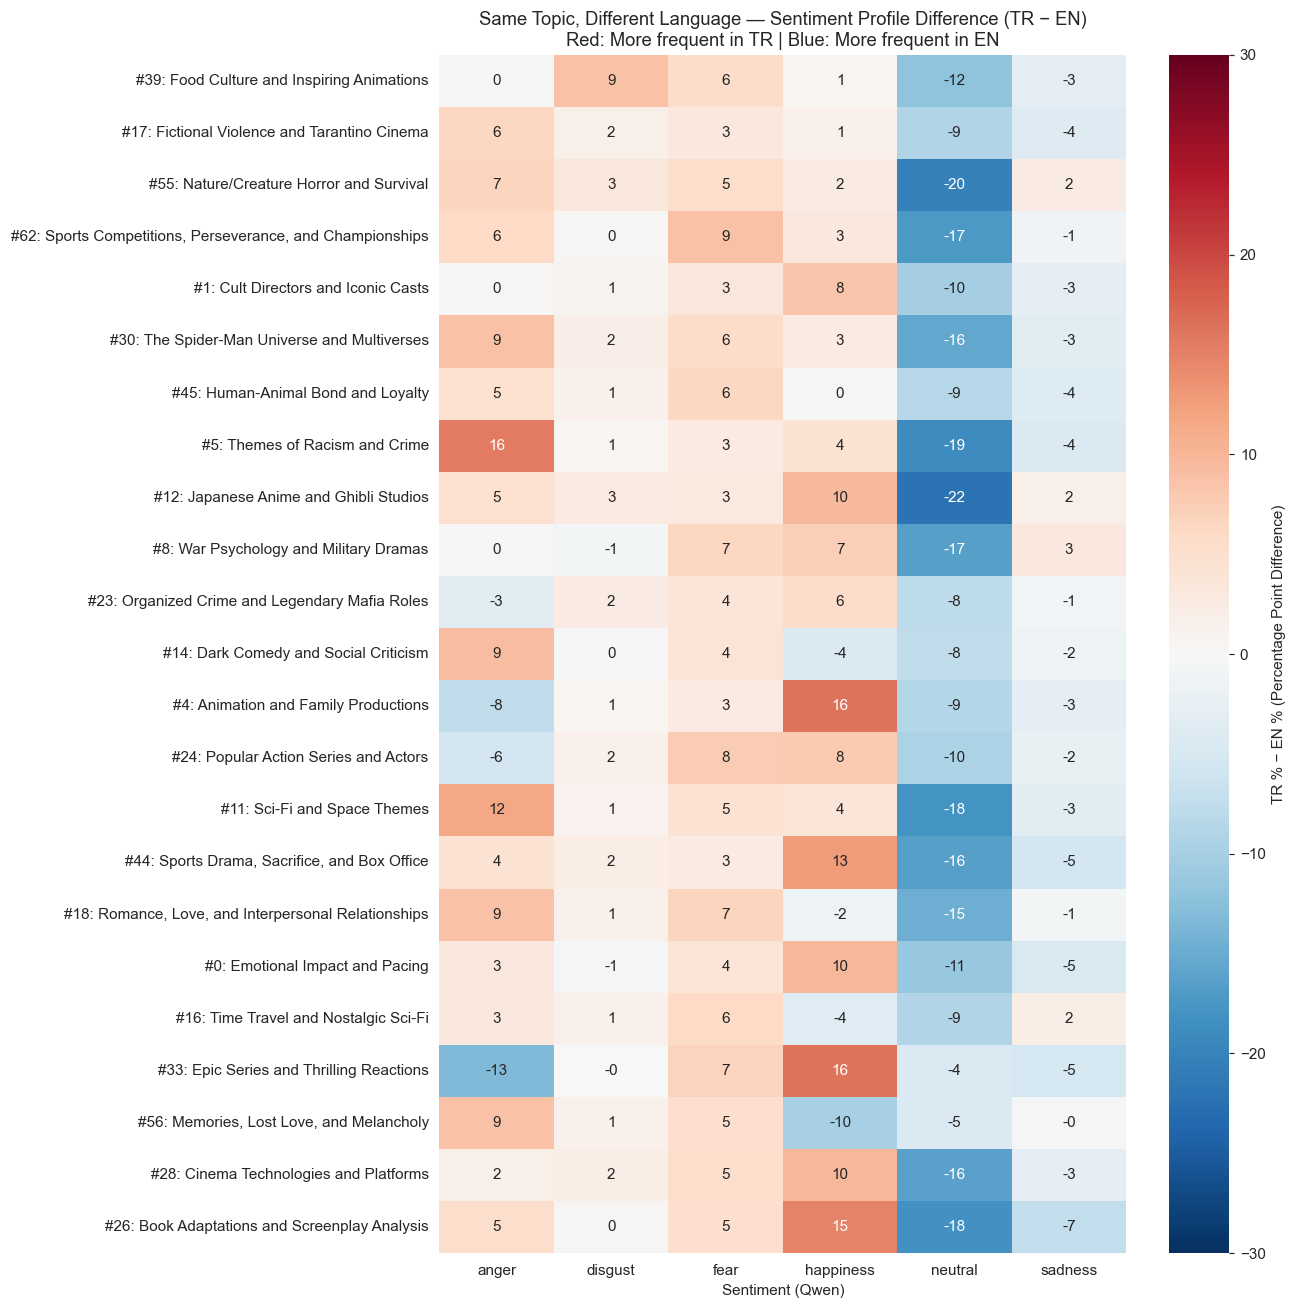

In [14]:
my_topics = [39, 17, 55, 62, 1, 30, 45, 5, 12, 8, 23, 14, 4, 24, 11, 44, 18, 0, 16, 33, 56, 28, 26]

rows = []
for t in my_topics:
    tr_dist = df_v[(df_v['topic']==t) & (df_v['language']=='tr')]['sentiment_qwen'].value_counts(normalize=True).reindex(EMO_ORDER).fillna(0) * 100
    en_dist = df_v[(df_v['topic']==t) & (df_v['language']=='en')]['sentiment_qwen'].value_counts(normalize=True).reindex(EMO_ORDER).fillna(0) * 100
    diff = tr_dist - en_dist 
    rows.append((t, diff))

labels = [f'#{r[0]}: {topic_title_dict.get(r[0], f"Topic {r[0]}")}' for r in rows]

diff_df = pd.DataFrame([r[1] for r in rows], index=labels)

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(diff_df, annot=True, fmt='.0f', cmap='RdBu_r', center=0, vmin=-30, vmax=30,
            cbar_kws={'label': 'TR % − EN % (Percentage Point Difference)'}, ax=ax)

ax.set_xlabel('Sentiment (Qwen)')
ax.set_ylabel('')

ax.set_title('Same Topic, Different Language — Sentiment Profile Difference (TR − EN)\nRed: More frequent in TR | Blue: More frequent in EN')

plt.tight_layout()

plt.savefig(FIG_DIR / 'same_topic_different_language_diff.png')
plt.show()

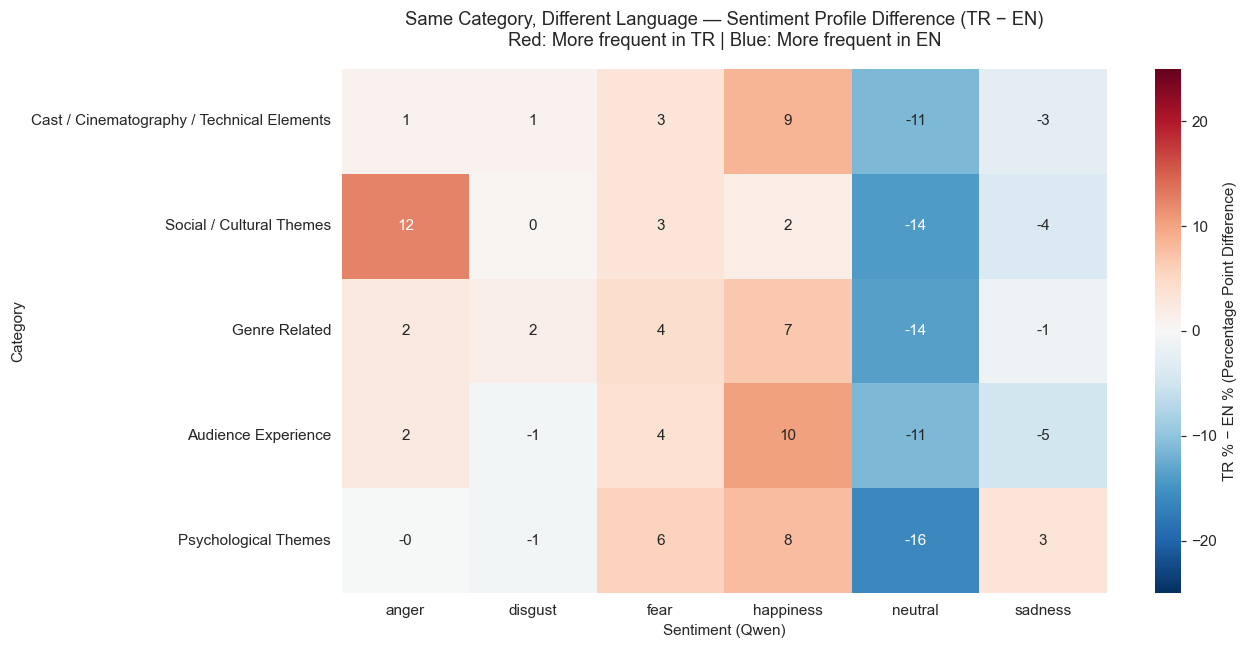

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_category_dict = dict(zip(topics_df['Topic'], topics_df['Category']))

df_v['category'] = df_v['topic'].map(topic_category_dict)

my_topics = [39, 17, 55, 62, 1, 30, 45, 5, 12, 8, 23, 14, 4, 24, 11, 44, 18, 0, 16, 33, 56, 28, 26]
df_filtered = df_v[df_v['topic'].isin(my_topics)].copy()

cat_rows = []
unique_categories = df_filtered['category'].dropna().unique()

for cat in unique_categories:
    cat_tr = df_filtered[(df_filtered['category'] == cat) & (df_filtered['language'] == 'tr')]['sentiment_qwen']
    cat_en = df_filtered[(df_filtered['category'] == cat) & (df_filtered['language'] == 'en')]['sentiment_qwen']
    
    if len(cat_tr) > 0 and len(cat_en) > 0:
        tr_dist = cat_tr.value_counts(normalize=True).reindex(EMO_ORDER).fillna(0) * 100
        en_dist = cat_en.value_counts(normalize=True).reindex(EMO_ORDER).fillna(0) * 100
        
        diff = tr_dist - en_dist
        cat_rows.append((cat, diff))

cat_diff_df = pd.DataFrame([r[1] for r in cat_rows], index=[r[0] for r in cat_rows])

fig, ax = plt.subplots(figsize=(12, max(6, 0.5 * len(cat_diff_df))))

sns.heatmap(cat_diff_df, annot=True, fmt='.0f', cmap='RdBu_r', center=0, vmin=-25, vmax=25,
            cbar_kws={'label': 'TR % − EN % (Percentage Point Difference)'}, ax=ax)

ax.set_xlabel('Sentiment (Qwen)')
ax.set_ylabel('Category')

ax.set_title('Same Category, Different Language — Sentiment Profile Difference (TR − EN)\nRed: More frequent in TR | Blue: More frequent in EN', pad=15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'same_category_different_language_diff.png', dpi=300)
plt.show()

## 5. Chi-Square Test of Independence

In [16]:
from scipy.stats import chi2_contingency
my_topics = [39, 17, 55, 62, 1, 30, 45, 5, 12, 8, 23, 14, 4, 24, 11, 44, 18, 0, 16, 33, 56, 28, 26]
df_chi = df[df['topic'].isin(my_topics)].copy()

contingency_table = pd.crosstab(df_chi['topic'], df_chi['sentiment_qwen'])
print('Contingency Table (Topics × Emotion)')
print('-' * 70)
print(contingency_table)
print()

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
n_total = contingency_table.values.sum()
cramer_v = np.sqrt(chi2_stat / (n_total * (min(contingency_table.shape) - 1)))

expected_df = pd.DataFrame(expected,
                            index=contingency_table.index,
                            columns=contingency_table.columns).round(1)

contingency_table.to_csv(FIG_DIR / 'chi_square_contingency_table.csv', encoding='utf-8-sig')
expected_df.to_csv(FIG_DIR / 'chi_square_expected_table.csv', encoding='utf-8-sig')
results_summary = pd.DataFrame([{
    'Test': 'Topics × Emotion',
    'n_topics': contingency_table.shape[0],
    'n_emotions': contingency_table.shape[1],
    'n_total': n_total,
    'chi_square': chi2_stat,
    'dof': dof,
    'p_value': p_value,
    'cramer_v': cramer_v,
    'decision': 'Reject H0' if p_value < 0.05 else 'Retain H0',
}])
results_summary.to_csv(FIG_DIR / 'chi_square_results.csv', index=False, encoding='utf-8-sig')
print()
print(f'Saved: {FIG_DIR}/chi_square_contingency_table.csv')
print(f'Saved: {FIG_DIR}/chi_square_expected_table.csv')
print(f'Saved: {FIG_DIR}/chi_square_results.csv')

Contingency Table (Topics × Emotion)
----------------------------------------------------------------------
sentiment_qwen  anger  disgust  fear  happiness  neutral  sadness
topic                                                            
0               14125     1721  5882      13697    12479     7627
1               12370     1745  4400      12421    14875     4896
4                1907      332   793       5276     3387     1364
5                3737      472  1473       1788     3209     1392
8                2915      292  1177       1471     2836     1152
11               2276      222   968       1806     2578      777
12               1918      318   654       1910     2697      839
14               2173      241   510       2367     1732      687
16               1404      185   531       2086     1878      600
17               1836      294   401       1448     1747      496
18               1652      225   476       1148     1172      530
23               1042      161   2